In [ ]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')


zip_path = '/content/drive/MyDrive/gastro_data.zip'
extract_path = '/content/gastro_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Mounted at /content/drive
Dataset unzipped successfully!


Using device: cuda
Starting training loop...
Epoch [1/10] | Loss D1: 1.2674, G1: 0.7318 | Loss D2: 0.0273, G2: 5.3999
Epoch [2/10] | Loss D1: 1.0837, G1: 1.1173 | Loss D2: 0.0359, G2: 5.9551
Epoch [3/10] | Loss D1: 0.9687, G1: 1.3634 | Loss D2: 0.0134, G2: 6.5334
Epoch [4/10] | Loss D1: 1.0199, G1: 1.5409 | Loss D2: 0.7098, G2: 19.0046
Epoch [5/10] | Loss D1: 0.9239, G1: 1.8404 | Loss D2: 0.0352, G2: 5.6943
Epoch [6/10] | Loss D1: 0.9221, G1: 1.8630 | Loss D2: 0.0145, G2: 6.3267
Epoch [7/10] | Loss D1: 0.9929, G1: 2.2320 | Loss D2: 0.0110, G2: 6.7771
Epoch [8/10] | Loss D1: 0.7749, G1: 2.1703 | Loss D2: 0.3232, G2: 18.4735
Epoch [9/10] | Loss D1: 0.7921, G1: 2.5398 | Loss D2: 0.0751, G2: 7.7120
Epoch [10/10] | Loss D1: 0.8736, G1: 2.5303 | Loss D2: 0.0151, G2: 7.7396


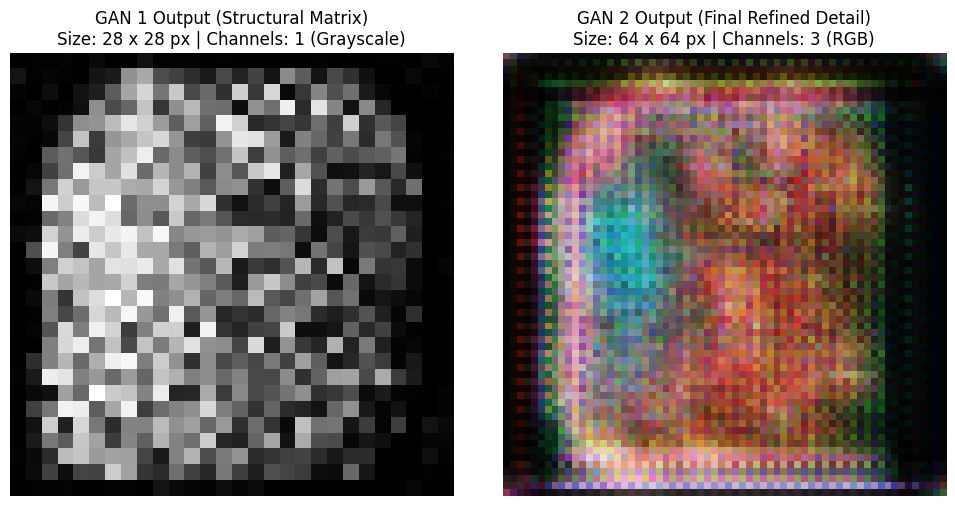


             IMAGE COMPARISON & STRUCTURAL AUDIT
• STAGE 1 (GAN 1) TENSOR SHAPE : [1, 1, 28, 28]
• STAGE 2 (GAN 2) TENSOR SHAPE : [1, 3, 64, 64]
------------------------------------------------------------
Architectural Breakdown:
1. GAN 1 acts as a 'global structural designer'. It works from pure noise
   to isolate boundaries and shape properties in a tight 28x28 matrix.
2. GAN 2 accepts the detached 28x28 matrix template, scales up spatial dimensions,
   and hallucinated RGB tissue pigmentation textures mapping up to 64x64.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

latent_dim = 100
lr = 0.0002
beta1 = 0.5
batch_size = 32
epochs = 10
dataset_root = '/content/gastro_dataset'

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

medical_dataset = datasets.ImageFolder(root=dataset_root, transform=transform)
dataloader = DataLoader(medical_dataset, batch_size=batch_size, shuffle=True, drop_last=True)


downscale_to_lowres = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28))
])


class Generator1(nn.Module):
    def __init__(self, latent_dim):
        super(Generator1, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1 * 28 * 28),
            nn.Tanh()
        )
    def forward(self, z):
        img = self.model(z)
        return img.view(img.size(0), 1, 28, 28)

class Discriminator1(nn.Module):
    def __init__(self):
        super(Discriminator1, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1 * 28 * 28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, img):
        return self.model(img)

class Generator2(nn.Module):
    def __init__(self):
        super(Generator2, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 3, kernel_size=6, stride=1, padding=0),
            nn.Tanh()
        )
    def forward(self, low_res_img):
        return self.network(low_res_img)

class Discriminator2(nn.Module):
    def __init__(self):
        super(Discriminator2, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 1),
            nn.Sigmoid()
        )
    def forward(self, img):
        return self.network(img)


netG1 = Generator1(latent_dim).to(device)
netD1 = Discriminator1().to(device)
netG2 = Generator2().to(device)
netD2 = Discriminator2().to(device)

criterion = nn.BCELoss()
optG1 = optim.Adam(netG1.parameters(), lr=lr, betas=(beta1, 0.999))
optD1 = optim.Adam(netD1.parameters(), lr=lr, betas=(beta1, 0.999))
optG2 = optim.Adam(netG2.parameters(), lr=lr, betas=(beta1, 0.999))
optD2 = optim.Adam(netD2.parameters(), lr=lr, betas=(beta1, 0.999))


print("Starting training loop...")

for epoch in range(epochs):
    for i, (real_high, _) in enumerate(dataloader):
        b_size = real_high.size(0)
        real_high = real_high.to(device)
        real_low = downscale_to_lowres(real_high).to(device)

        label_real = torch.ones(b_size, 1).to(device)
        label_fake = torch.zeros(b_size, 1).to(device)


        netD1.zero_grad()
        outD1_real = netD1(real_low)
        lossD1_real = criterion(outD1_real, label_real)

        z = torch.randn(b_size, latent_dim).to(device)
        fake_low = netG1(z)
        outD1_fake = netD1(fake_low.detach())
        lossD1_fake = criterion(outD1_fake, label_fake)
        lossD1 = lossD1_real + lossD1_fake
        lossD1.backward()
        optD1.step()

        netG1.zero_grad()
        outD1_fake_for_G = netD1(fake_low)
        lossG1 = criterion(outD1_fake_for_G, label_real)
        lossG1.backward()
        optG1.step()


        input_for_G2 = fake_low.detach()

        netD2.zero_grad()
        outD2_real = netD2(real_high)
        lossD2_real = criterion(outD2_real, label_real)

        fake_high = netG2(input_for_G2)
        outD2_fake = netD2(fake_high.detach())
        lossD2_fake = criterion(outD2_fake, label_fake)
        lossD2 = lossD2_real + lossD2_fake
        lossD2.backward()
        optD2.step()

        netG2.zero_grad()
        outD2_fake_for_G = netD2(fake_high)
        lossG2 = criterion(outD2_fake_for_G, label_real)
        lossG2.backward()
        optG2.step()

    print(f"Epoch [{epoch+1}/{epochs}] | Loss D1: {lossD1.item():.4f}, G1: {lossG1.item():.4f} | Loss D2: {lossD2.item():.4f}, G2: {lossG2.item():.4f}")


netG1.eval()
netG2.eval()

with torch.no_grad():

    test_z = torch.randn(1, latent_dim).to(device)


    gan1_output = netG1(test_z)


    gan2_output = netG2(gan1_output)


img_stage1 = gan1_output.squeeze().cpu().numpy()

img_stage1 = (img_stage1 + 1) / 2


img_stage2 = gan2_output.squeeze().permute(1, 2, 0).cpu().numpy()
img_stage2 = (img_stage2 + 1) / 2


fig, axes = plt.subplots(1, 2, figsize=(10, 5))


axes[0].imshow(img_stage1, cmap='gray')
axes[0].set_title("GAN 1 Output (Structural Matrix)\nSize: 28 x 28 px | Channels: 1 (Grayscale)")
axes[0].axis('off')


axes[1].imshow(img_stage2)
axes[1].set_title("GAN 2 Output (Final Refined Detail)\nSize: 64 x 64 px | Channels: 3 (RGB)")
axes[1].axis('off')

plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("             IMAGE COMPARISON & STRUCTURAL AUDIT")
print("="*60)
print(f"• STAGE 1 (GAN 1) TENSOR SHAPE : {list(gan1_output.shape)}")
print(f"• STAGE 2 (GAN 2) TENSOR SHAPE : {list(gan2_output.shape)}")
print("-"*60)
print("Architectural Breakdown:")
print("1. GAN 1 acts as a 'global structural designer'. It works from pure noise")
print("   to isolate boundaries and shape properties in a tight 28x28 matrix.")
print("2. GAN 2 accepts the detached 28x28 matrix template, scales up spatial dimensions,")
print("   and hallucinated RGB tissue pigmentation textures mapping up to 64x64.")
print("="*60)

Image Classes: ['gastro_data']


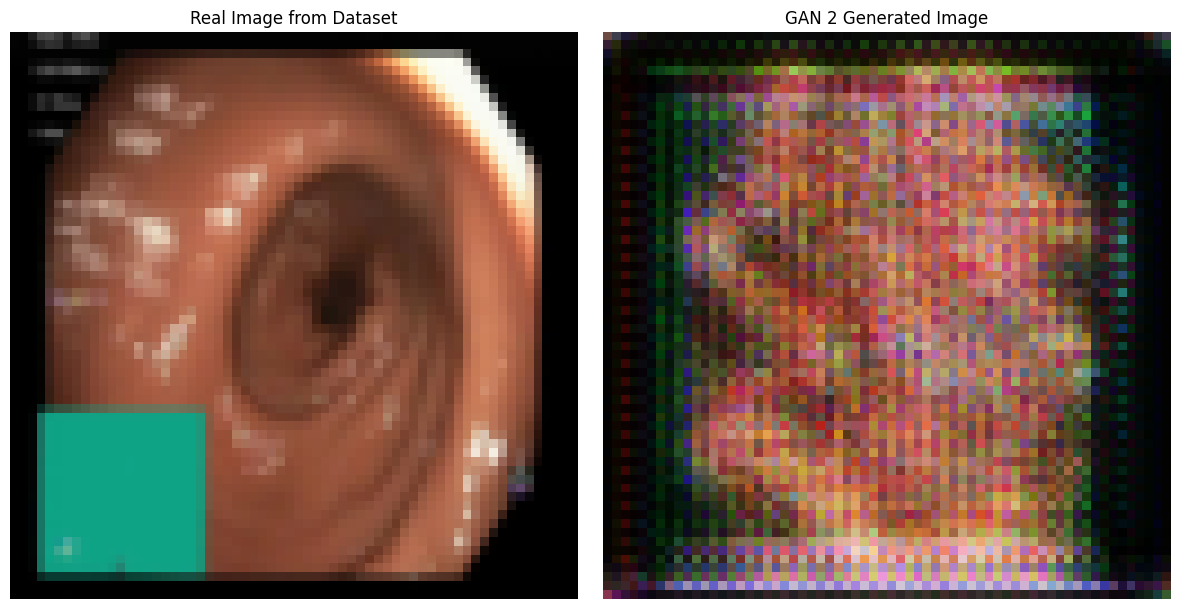

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np


print(f"Image Classes: {medical_dataset.classes}")


try:

    real_image_batch, _ = next(iter(dataloader))
    real_image_to_display = real_image_batch[random.randint(0, real_image_batch.shape[0] - 1)]
except StopIteration:

    print("Dataloader exhausted, re-initializing for a single image.")

    idx = random.randint(0, len(medical_dataset) - 1)
    real_image_to_display, _ = medical_dataset[idx]


real_image_np = real_image_to_display.permute(1, 2, 0).cpu().numpy() # Channel last for imshow
real_image_np = (real_image_np * 0.5) + 0.5 # De-normalize
real_image_np = np.clip(real_image_np, 0, 1) # Clip to ensure valid pixel values

netG1.eval()
netG2.eval()

with torch.no_grad():
    test_z = torch.randn(1, latent_dim).to(device)
    gan1_output = netG1(test_z)
    gan2_output = netG2(gan1_output)

img_stage2 = gan2_output.squeeze().permute(1, 2, 0).cpu().numpy()
img_stage2 = (img_stage2 + 1) / 2 # De-normalize from [-1, 1] to [0, 1]
img_stage2 = np.clip(img_stage2, 0, 1) # Clip to ensure valid pixel values


fig, axes = plt.subplots(1, 2, figsize=(12, 6))


axes[0].imshow(real_image_np)
axes[0].set_title("Real Image from Dataset")
axes[0].axis('off')


axes[1].imshow(img_stage2)
axes[1].set_title("GAN 2 Generated Image")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class DC_Generator(nn.Module):
    def __init__(self, latent_dim):
        super(DC_Generator, self).__init__()
        self.main = nn.Sequential(

            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # State size: 512 x 4 x 4
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # State size: 256 x 8 x 8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # State size: 128 x 16 x 16
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # State size: 64 x 32 x 32
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
            # Final state size: 3 x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

class DC_Discriminator(nn.Module):
    def __init__(self):
        super(DC_Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input is 3 x 64 x 64
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: 64 x 32 x 32
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: 128 x 16 x 16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: 256 x 8 x 8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: 512 x 4 x 4
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1)

# Instantiate new models
netG = DC_Generator(latent_dim).to(device)
netG.apply(weights_init)

netD = DC_Discriminator().to(device)
netD.apply(weights_init)

optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))

print("DCGAN Architecture ready. Run a training loop with these models for better realism.")

DCGAN Architecture ready. Run a training loop with these models for better realism.


Starting DCGAN Training Loop...
[0/5][0/25] Loss_D: 0.0001 Loss_G: 37.5035 D(x): 0.9999 D(G(z)): 0.0000 / 0.0000


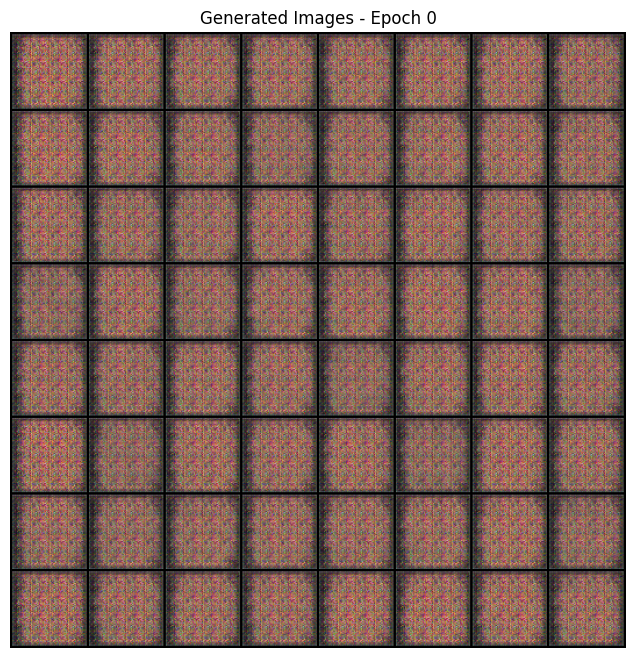

[1/5][0/25] Loss_D: 0.0000 Loss_G: 37.5154 D(x): 1.0000 D(G(z)): 0.0000 / 0.0000


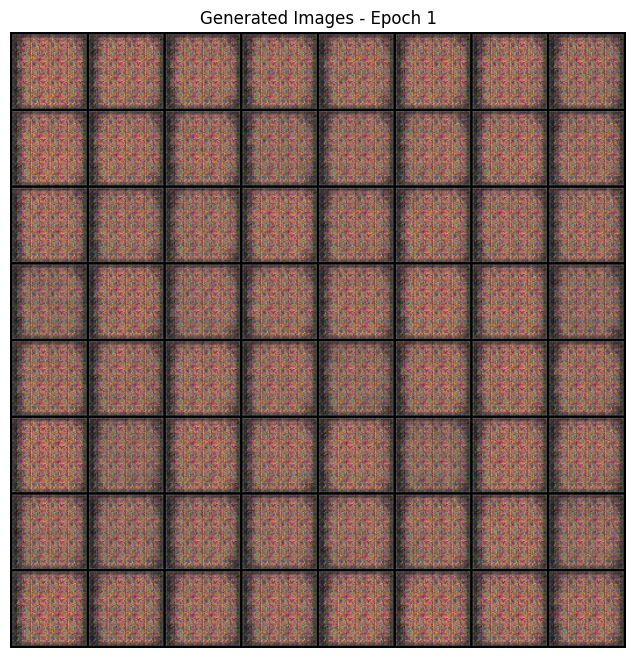

[2/5][0/25] Loss_D: 0.0000 Loss_G: 37.4595 D(x): 1.0000 D(G(z)): 0.0000 / 0.0000


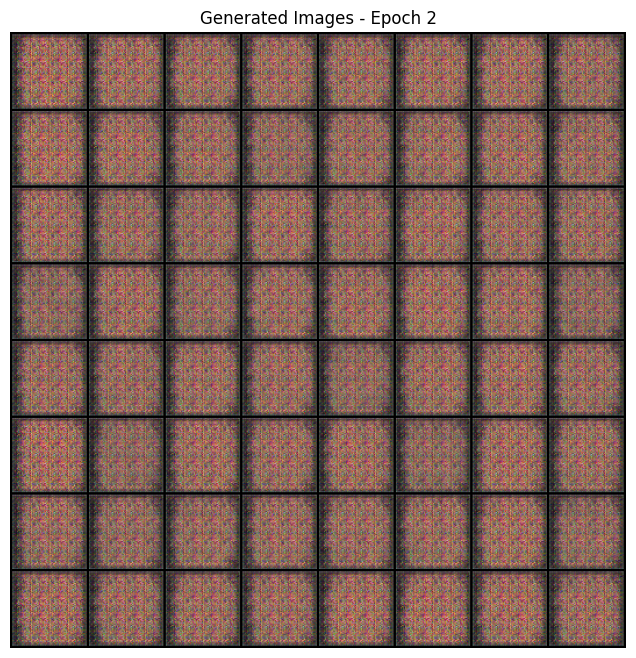

[3/5][0/25] Loss_D: 0.0001 Loss_G: 37.5208 D(x): 0.9999 D(G(z)): 0.0000 / 0.0000


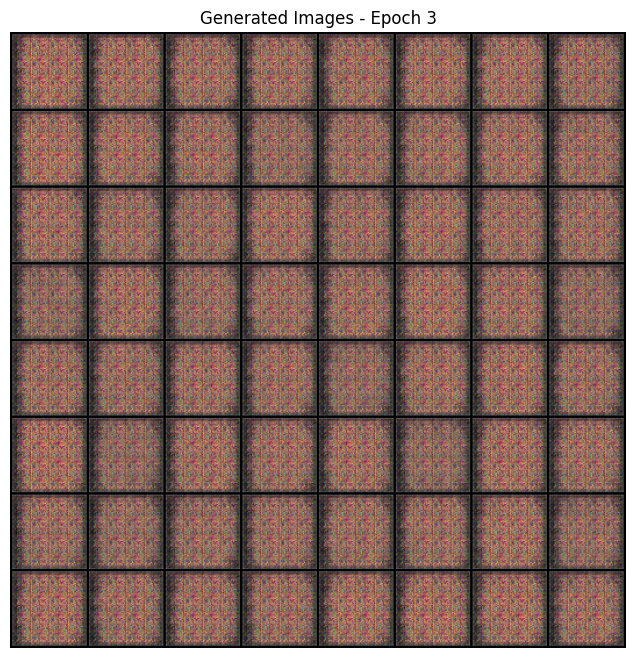

[4/5][0/25] Loss_D: 0.0002 Loss_G: 37.4871 D(x): 0.9998 D(G(z)): 0.0000 / 0.0000


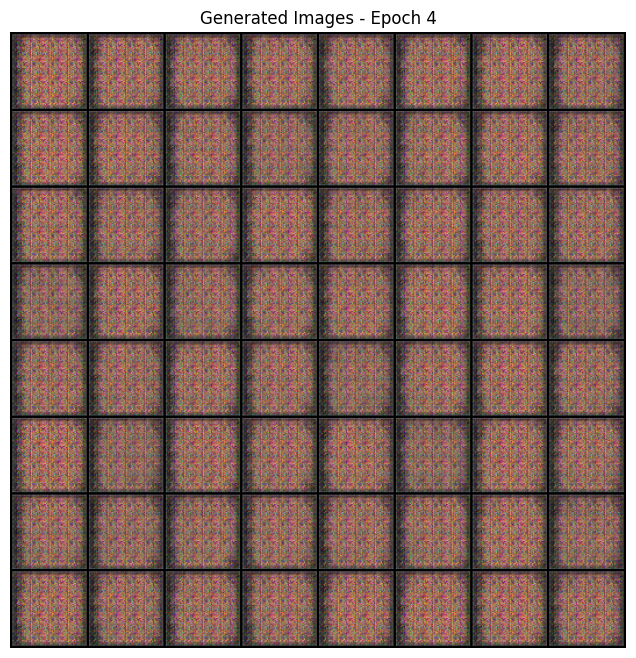

In [ ]:
import torch
import torchvision.utils as vutils

# Hyperparameters for training
num_epochs = 5
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

print("Starting DCGAN Training Loop...")

for epoch in range(num_epochs):
    for i, (data, _) in enumerate(dataloader):
        # 1. Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 1.0, dtype=torch.float, device=device)

        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        # 2. Update Generator: maximize log(D(G(z)))
        netG.zero_grad()
        label.fill_(1.0)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        if i % 50 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')

    # Visualization after each epoch
    with torch.no_grad():
        fake = netG(fixed_noise).detach().cpu()
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title(f"Generated Images - Epoch {epoch}")
    plt.imshow(np.transpose(vutils.make_grid(fake, padding=2, normalize=True), (1,2,0)))
    plt.show()

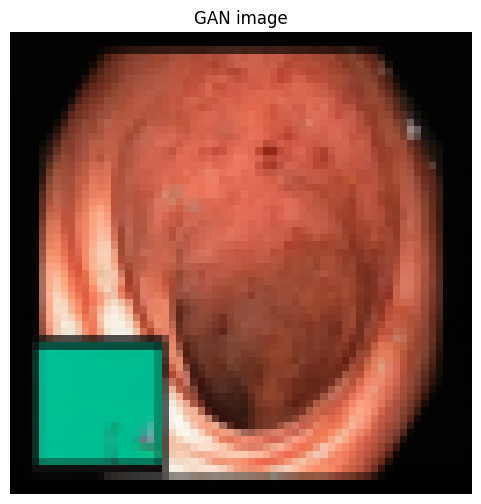

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random


idx = random.randint(0, len(medical_dataset) - 1)
real_img_tensor, _ = medical_dataset[idx]


img_display = real_img_tensor.permute(1, 2, 0).cpu().numpy()
img_display = (img_display * 0.5) + 0.5
img_display = np.clip(img_display, 0, 1)


plt.figure(figsize=(6, 6))
plt.imshow(img_display)
plt.title("GAN image")
plt.axis('off')
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Ensure stage 1 and 2 models are available if not already in memory
# (Assuming they were defined in previous cells 9ko59D0MWigx)

class Generator3(nn.Module):
    def __init__(self):
        super(Generator3, self).__init__()
        # Input: 3 x 64 x 64 (from GAN 2)
        self.network = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1), # Up to 128x128
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Conv2d(32, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )
    def forward(self, x):
        return self.network(x)

class Discriminator3(nn.Module):
    def __init__(self):
        super(Discriminator3, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1), # 64x64
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 32x32
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 32 * 32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

# Initialize Stage 3
netG3 = Generator3().to(device)
netD3 = Discriminator3().to(device)
optG3 = optim.Adam(netG3.parameters(), lr=lr, betas=(beta1, 0.999))
optD3 = optim.Adam(netD3.parameters(), lr=lr, betas=(beta1, 0.999))

# Target transform for 128x128 real images for stage 3 training
transform_128 = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
dataloader_128 = DataLoader(datasets.ImageFolder(root=dataset_root, transform=transform_128), batch_size=batch_size, shuffle=True, drop_last=True)

print("Training Stage 3 GAN...")
for epoch in range(3): # Short training for demonstration
    for i, (real_128, _) in enumerate(dataloader_128):
        b_size = real_128.size(0)
        real_128 = real_128.to(device)

        # Prepare labels
        label_real = torch.ones(b_size, 1).to(device)
        label_fake = torch.zeros(b_size, 1).to(device)

        # Train D3
        netD3.zero_grad()
        outD3_real = netD3(real_128)
        lossD3_real = criterion(outD3_real, label_real)

        # Simulate inputs from Stage 2 (or use real 64x64 data for training efficiency)
        input_64 = transforms.Resize((64, 64))(real_128)
        fake_128 = netG3(input_64)

        outD3_fake = netD3(fake_128.detach())
        lossD3_fake = criterion(outD3_fake, label_fake)
        lossD3 = lossD3_real + lossD3_fake
        lossD3.backward()
        optD3.step()

        # Train G3
        netG3.zero_grad()
        outD3_fake_for_G = netD3(fake_128)
        lossG3 = criterion(outD3_fake_for_G, label_real)
        lossG3.backward()
        optG3.step()
    print(f"Epoch [{epoch+1}/3] Loss D3: {lossD3.item():.4f}, G3: {lossG3.item():.4f}")

# Inference
netG1.eval(); netG2.eval(); netG3.eval()
with torch.no_grad():
    z = torch.randn(1, latent_dim).to(device)
    s1 = netG1(z)     # 28x28
    s2 = netG2(s1)    # 64x64
    s3 = netG3(s2)    # 128x128

plt.imshow((s3.squeeze().permute(1,2,0).cpu().numpy() + 1)/2)
plt.title("Final 128x128 Output from 3-Stage GAN")
plt.axis('off')
plt.show()

NameError: name 'nn' is not defined